In [3]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import spearmanr

from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt

In [2]:
data = pd.read_pickle("../data/processed/transcript_embeddings.pkl")
print(data.shape)
print(data.head(5))

(13715, 5)
  ticker       date    ret_1m    ret_3m  \
0      A 2020-02-18 -0.187758 -0.010816   
1      A 2020-05-21  0.096347  0.213440   
2      A 2020-08-18  0.017780  0.128846   
3      A 2020-11-23  0.045361  0.089923   
4      A 2021-02-16 -0.042439  0.018429   

                                transcript_embedding  
0  [-0.04184066, -0.024315318, 0.03424357, -0.013...  
1  [-0.042391513, -0.02445699, 0.031295378, -0.01...  
2  [-0.027920121, -0.040649388, 0.021861328, -0.0...  
3  [-0.030878326, -0.029609961, 0.023083668, -0.0...  
4  [-0.043922257, -0.039932363, 0.023395421, -0.0...  


In [3]:
# convert embedding -> feature matrix
# x = language festures, y = future returns
x = np.vstack(data["transcript_embedding"].values)
y = data["ret_1m"].values
print(x.shape)

(13715, 384)


In [4]:
# train model
# model learns relationship between earning call language -> future returns
model = LinearRegression()
model.fit(x, y)

LinearRegression()

In [5]:
# predict for all earnings
data["predicted_return"] = model.predict(x)
data.head()

,ticker,date,ret_1m,ret_3m,transcript_embedding,predicted_return
0,A,2020-02-18,-0.187758,-0.010816,"[-0.04184066, -0.024315318, 0.03424357, -0.013...",0.021732
1,A,2020-05-21,0.096347,0.213440,"[-0.042391513, -0.02445699, 0.031295378, -0.01...",0.083876
2,A,2020-08-18,0.017780,0.128846,"[-0.027920121, -0.040649388, 0.021861328, -0.0...",0.060015
3,A,2020-11-23,0.045361,0.089923,"[-0.030878326, -0.029609961, 0.023083668, -0.0...",0.083908
4,A,2021-02-16,-0.042439,0.018429,"[-0.043922257, -0.039932363, 0.023395421, -0.0...",0.044860


In [6]:
# convert prediction to ranking
data["rank"] = data["predicted_return"].rank(pct=True)
data[["predicted_return", "rank"]].head()

,predicted_return,rank
0,0.021732,0.609770
1,0.083876,0.937441
2,0.060015,0.856580
3,0.083908,0.937659
4,0.044860,0.771491


In [7]:
# build portfolio
long_portfolio = data[data["rank"] >= 0.8]
short_portfolio = data[data["rank"] <= 0.2]

print("Long stocks:", len(long_portfolio))
print("Short stocks:", len(short_portfolio))

Long stocks: 2744
Short stocks: 2743


In [8]:
# compute portfolio returns
long_return = long_portfolio["ret_1m"].mean()
short_return = short_portfolio["ret_1m"].mean()

long_short_return = long_return - short_return

print("Long portfolio return:", long_return)
print("Short portfolio return:", short_return)
print("Long-Short alpha:", long_short_return)

Long portfolio return: 0.072997371106183
Short portfolio return: -0.0548887525612305
Long-Short alpha: 0.1278861236674135


Time Series Backtest

In [ ]:
# monthly basis
data["month"] = data["date"].dt.to_period("M")

In [ ]:
# monthly basis Long-Short Calculation
monthly_returns = []

for month, group in data.groupby("month"):
    
    group = group.copy()
    
    # Rank within that month
    group["rank"] = group["predicted_return"].rank(pct=True)
    
    long = group[group["rank"] >= 0.8]
    short = group[group["rank"] <= 0.2]
    
    if len(long) > 0 and len(short) > 0:
        long_ret = long["ret_1m"].mean()
        short_ret = short["ret_1m"].mean()
        spread = long_ret - short_ret
        
        monthly_returns.append({
            "month": month,
            "long_return": long_ret,
            "short_return": short_ret,
            "long_short": spread
        })

monthly_df = pd.DataFrame(monthly_returns)
monthly_df.head(10)

,month,long_return,short_return,long_short
0,2019-05,0.100792,-0.005149,0.105941
1,2019-06,0.036822,0.084231,-0.047409
2,2019-07,-0.027223,-0.018920,-0.008302
3,2019-08,0.008329,0.022198,-0.013869
4,2019-09,-0.052457,-0.059265,0.006808
5,2019-10,0.038944,0.021510,0.017434
6,2019-11,0.029996,-0.009706,0.039703
7,2019-12,0.013668,0.064170,-0.050502
8,2020-01,-0.054523,-0.074421,0.019897
9,2020-02,-0.199963,-0.299988,0.100025


In [ ]:
# cumulative portfolio growth
monthly_df = monthly_df.sort_values("month")

monthly_df["cumulative"] = (1 + monthly_df["long_short"]).cumprod()

monthly_df.tail(10)

,month,long_return,short_return,long_short,cumulative
36,2022-05,0.079051,-0.037516,0.116567,9.237749
37,2022-06,0.022777,-0.117896,0.140673,10.537249
38,2022-07,0.064629,0.011078,0.053551,11.101525
39,2022-08,-0.022873,-0.139338,0.116464,12.394455
40,2022-09,-0.001023,-0.122054,0.121031,13.894574
41,2022-10,0.118774,0.036811,0.081964,15.033423
42,2022-11,0.112545,-0.006041,0.118586,16.816184
43,2022-12,0.037630,-0.036372,0.074002,18.060616
44,2023-01,-0.007472,-0.004577,-0.002894,18.008340
45,2023-02,-0.020332,-0.100453,0.080121,19.451178


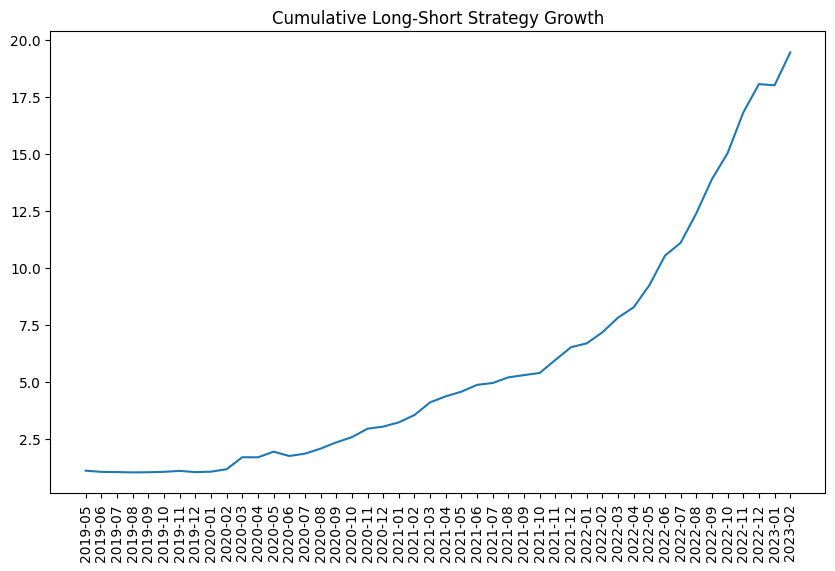

In [13]:
# plot growth
plt.figure(figsize=(10,6))
plt.plot(monthly_df["month"].astype(str), monthly_df["cumulative"])
plt.xticks(rotation=90)
plt.title("Cumulative Long-Short Strategy Growth")
plt.show()

In [14]:
returns = monthly_df["long_short"]

In [ ]:
n_months = len(returns)
annual_return = (monthly_df["cumulative"].iloc[-1])**(12/n_months) - 1

print("Annualized Return:", annual_return)

Annualized Return: 1.1689361137786074


In [16]:
annual_vol = returns.std() * np.sqrt(12)

print("Annualized Volatility:", annual_vol)

Annualized Volatility: 0.28050113097706786


In [17]:
sharpe = annual_return / annual_vol

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 4.167313371275401


In [18]:
rolling_max = monthly_df["cumulative"].cummax()
drawdown = monthly_df["cumulative"] / rolling_max - 1

max_drawdown = drawdown.min()

print("Max Drawdown:", max_drawdown)

Max Drawdown: -0.09820903426539918


robust test #1 : trade Lag 1 month

In [19]:
data["month"] = data["date"].dt.to_period("M")
data.head()

,ticker,date,ret_1m,ret_3m,transcript_embedding,predicted_return,rank,month
0,A,2020-02-18,-0.187758,-0.010816,"[-0.04184066, -0.024315318, 0.03424357, -0.013...",0.021732,0.609770,2020-02
1,A,2020-05-21,0.096347,0.213440,"[-0.042391513, -0.02445699, 0.031295378, -0.01...",0.083876,0.937441,2020-05
2,A,2020-08-18,0.017780,0.128846,"[-0.027920121, -0.040649388, 0.021861328, -0.0...",0.060015,0.856580,2020-08
3,A,2020-11-23,0.045361,0.089923,"[-0.030878326, -0.029609961, 0.023083668, -0.0...",0.083908,0.937659,2020-11
4,A,2021-02-16,-0.042439,0.018429,"[-0.043922257, -0.039932363, 0.023395421, -0.0...",0.044860,0.771491,2021-02


In [20]:
# shift predictions forward one month per ticker
data = data.sort_values(["ticker","date"])

data["predicted_return_lagged"] = (
    data.groupby("ticker")["predicted_return"].shift(1)
)

# remove rows where lagged signal doesn't exist
data_lagged = data.dropna(subset=["predicted_return_lagged"]).copy()

In [23]:
monthly_returns_lagged = []

for month, group in data_lagged.groupby("month"):
    
    group = group.copy()
    
    group["rank"] = group["predicted_return_lagged"].rank(pct=True)
    
    long = group[group["rank"] >= 0.8]
    short = group[group["rank"] <= 0.2]
    
    if len(long) > 0 and len(short) > 0:
        long_ret = long["ret_1m"].mean()
        short_ret = short["ret_1m"].mean()
        spread = long_ret - short_ret
        
        monthly_returns_lagged.append({
            "month": month,
            "long_short": spread
        })

monthly_lagged_df = pd.DataFrame(monthly_returns_lagged)
monthly_lagged_df.head()

,month,long_short
0,2019-08,-0.168706
1,2019-09,-0.184952
2,2019-10,0.029067
3,2019-11,-0.005752
4,2019-12,0.010459


In [24]:
monthly_lagged_df = monthly_lagged_df.sort_values("month")
monthly_lagged_df["cumulative"] = (1 + monthly_lagged_df["long_short"]).cumprod()

In [25]:
returns = monthly_lagged_df["long_short"]

n_months = len(returns)
annual_return = (monthly_lagged_df["cumulative"].iloc[-1])**(12/n_months) - 1
annual_vol = returns.std() * np.sqrt(12)
sharpe = annual_return / annual_vol

rolling_max = monthly_lagged_df["cumulative"].cummax()
drawdown = monthly_lagged_df["cumulative"] / rolling_max - 1
max_dd = drawdown.min()

print("Annual Return:", annual_return)
print("Volatility:", annual_vol)
print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)

Annual Return: 0.5895097431728504
Volatility: 0.27917683419221634
Sharpe: 2.1115997854140236
Max Drawdown: -0.1849517735834708


robust test #2 : transaction costs on the lagged data

In [26]:
cost = 0.01   # 1% monthly cost

monthly_lagged_df["long_short_net"] = (
    monthly_lagged_df["long_short"] - cost
)

In [27]:
# recompute cumulative growth
monthly_lagged_df["cumulative_net"] = (
    1 + monthly_lagged_df["long_short_net"]
).cumprod()

In [28]:
# recompute metrics
returns = monthly_lagged_df["long_short_net"]

n_months = len(returns)

annual_return = (monthly_lagged_df["cumulative_net"].iloc[-1])**(12/n_months) - 1
annual_vol = returns.std() * np.sqrt(12)
sharpe = annual_return / annual_vol

rolling_max = monthly_lagged_df["cumulative_net"].cummax()
drawdown = monthly_lagged_df["cumulative_net"] / rolling_max - 1
max_dd = drawdown.min()

print("Annual Return:", annual_return)
print("Volatility:", annual_vol)
print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)

Annual Return: 0.41489112509653436
Volatility: 0.2791768341922164
Sharpe: 1.4861230384569701
Max Drawdown: -0.21201395986915283


robust test #3 : strong signals only(we buy top 20% and short bottom 20%)(from that we take top 10% and bottom 10%)

In [29]:
monthly_returns_strict = []

for month, group in data_lagged.groupby("month"):
    
    group = group.copy()
    group["rank"] = group["predicted_return_lagged"].rank(pct=True)
    
    long = group[group["rank"] >= 0.9]   # top 10%
    short = group[group["rank"] <= 0.1]  # bottom 10%
    
    if len(long) > 0 and len(short) > 0:
        spread = long["ret_1m"].mean() - short["ret_1m"].mean()
        monthly_returns_strict.append({"month": month, "spread": spread})

strict_df = pd.DataFrame(monthly_returns_strict)

In [30]:
cost = 0.01
strict_df["spread_net"] = strict_df["spread"] - cost
strict_df["cumulative"] = (1 + strict_df["spread_net"]).cumprod()

In [31]:
returns = strict_df["spread_net"]

# number of months
n_months = len(returns)

# Annualized Return (CAGR)
annual_return = (strict_df["cumulative"].iloc[-1])**(12/n_months) - 1

# Annualized Volatility
annual_vol = returns.std() * np.sqrt(12)

# Sharpe Ratio
sharpe = annual_return / annual_vol

# Maximum Drawdown
rolling_max = strict_df["cumulative"].cummax()
drawdown = strict_df["cumulative"] / rolling_max - 1
max_dd = drawdown.min()

print("Annual Return:", annual_return)
print("Volatility:", annual_vol)
print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)

Annual Return: 0.5589927986026648
Volatility: 0.28859069893623623
Sharpe: 1.9369744093040697
Max Drawdown: -0.2909402971954751


robust test #4 : train on past trade the future

In [4]:
data = pd.read_pickle("../data/processed/transcript_embeddings.pkl")
data["year"] = data["date"].dt.year

In [5]:
train_data = data[data["year"] <= 2021].copy()
test_data  = data[data["year"] >= 2022].copy()

print(len(train_data), len(test_data))

10240 3475


In [6]:
X_train = np.vstack(train_data["transcript_embedding"])
y_train = train_data["ret_1m"]

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [7]:
X_test = np.vstack(test_data["transcript_embedding"])

test_data["predicted_return"] = model.predict(X_test)

In [8]:
test_data.to_pickle("../data/processed/test_predictions.pkl")

In [9]:
test_data = pd.read_pickle("../data/processed/test_predictions.pkl")

In [10]:

# 1. Ensure date & month format
test_data["month"] = test_data["date"].dt.to_period("M")

# 2. Lag predictions by ticker
test_data = test_data.sort_values(["ticker", "date"])

test_data["predicted_return_lagged"] = (
    test_data.groupby("ticker")["predicted_return"].shift(1)
)
# Remove rows without lagged prediction
test_data = test_data.dropna(subset=["predicted_return_lagged"])

# 3. Monthly ranking (Top 10 / Bottom 10)
monthly_results = []

for month, group in test_data.groupby("month"):
    
    group = group.copy()
    
    # percentile ranking
    group["rank"] = group["predicted_return_lagged"].rank(pct=True)
    
    long = group[group["rank"] >= 0.9]
    short = group[group["rank"] <= 0.1]
    
    if len(long) > 0 and len(short) > 0:
        spread = long["ret_1m"].mean() - short["ret_1m"].mean()
        
        monthly_results.append({
            "month": month,
            "spread": spread
        })

strict_df = pd.DataFrame(monthly_results)


# 4. Apply transaction cost
cost = 0.01
strict_df["spread_net"] = strict_df["spread"] - cost

# 5. Compute cumulative return
strict_df["cumulative"] = (1 + strict_df["spread_net"]).cumprod()

# 6. Compute Metrics
returns = strict_df["spread_net"]
n_months = len(returns)

# Annualized Return (CAGR)
annual_return = strict_df["cumulative"].iloc[-1]**(12/n_months) - 1

# Annualized Volatility
annual_vol = returns.std() * np.sqrt(12)

# Sharpe Ratio
sharpe = annual_return / annual_vol

# Max Drawdown
rolling_max = strict_df["cumulative"].cummax()
drawdown = strict_df["cumulative"] / rolling_max - 1
max_dd = drawdown.min()

print("Annual Return:", annual_return)
print("Volatility:", annual_vol)
print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)

Annual Return: 0.3414893586620873
Volatility: 0.2301946995407483
Sharpe: 1.483480546439072
Max Drawdown: -0.07835816136376417


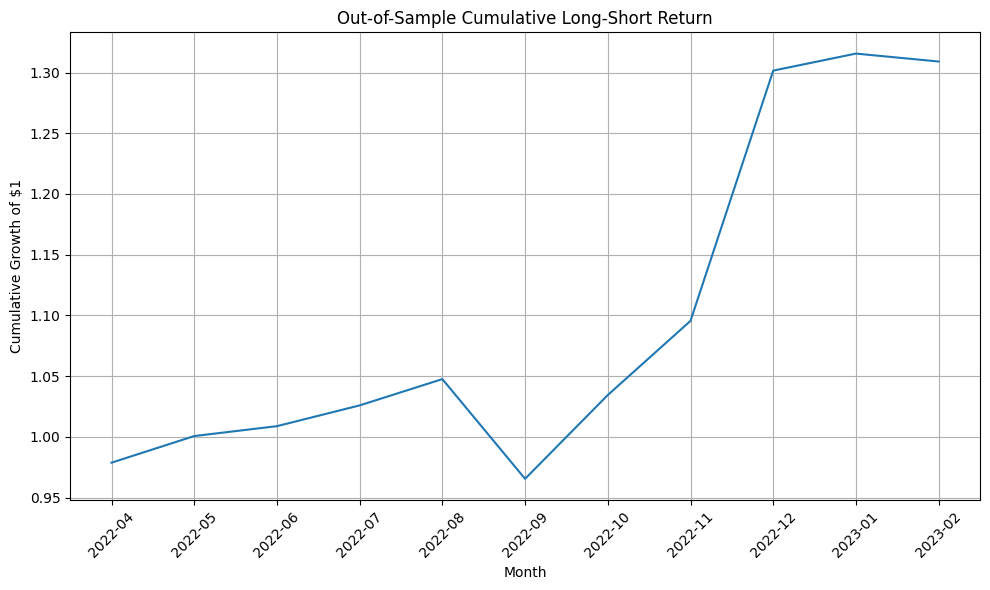

In [11]:
# cumulative return plot
plt.figure(figsize=(10,6))
plt.plot(strict_df["month"].astype(str), strict_df["cumulative"])
plt.xticks(rotation=45)
plt.title("Out-of-Sample Cumulative Long-Short Return")
plt.xlabel("Month")
plt.ylabel("Cumulative Growth of $1")
plt.grid(True)
plt.tight_layout()
plt.show()

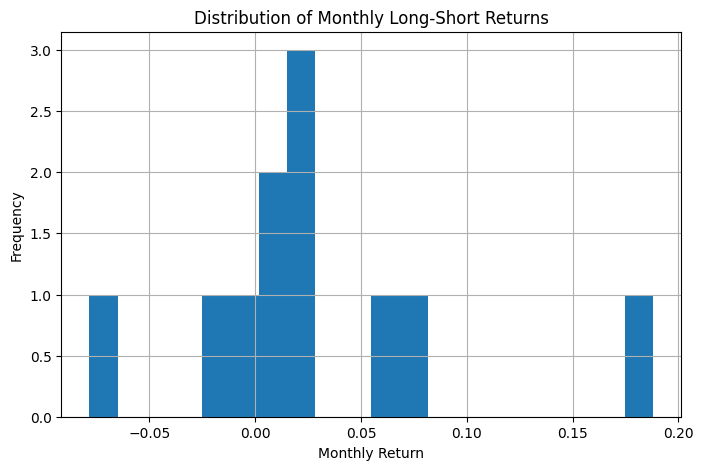

In [40]:
# monthly return distribution
plt.figure(figsize=(8,5))
plt.hist(strict_df["spread_net"], bins=20)
plt.title("Distribution of Monthly Long-Short Returns")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

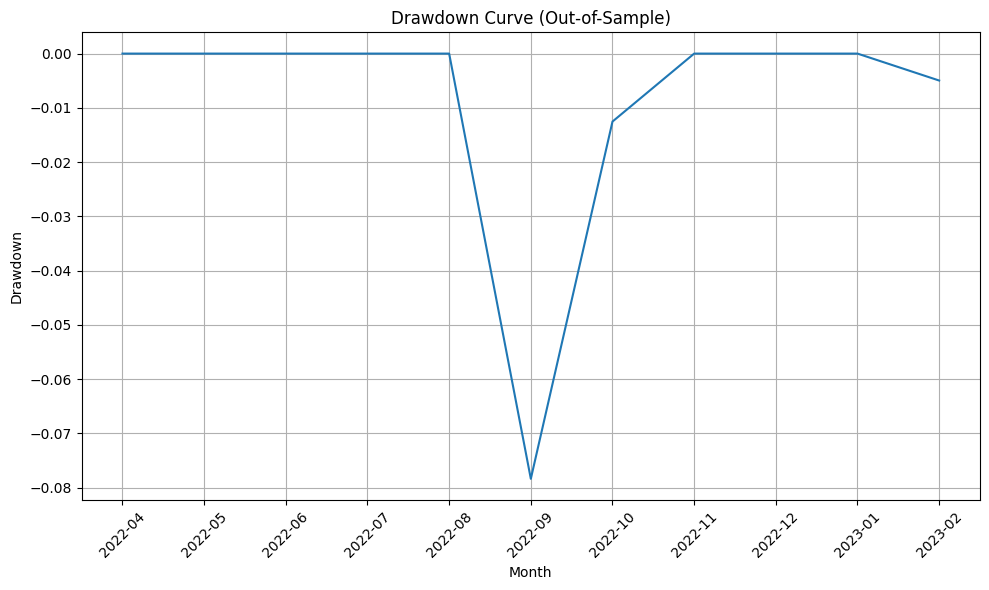

In [41]:
# drawdown curve
rolling_max = strict_df["cumulative"].cummax()
drawdown = strict_df["cumulative"] / rolling_max - 1

plt.figure(figsize=(10,6))
plt.plot(strict_df["month"].astype(str), drawdown)
plt.xticks(rotation=45)
plt.title("Drawdown Curve (Out-of-Sample)")
plt.xlabel("Month")
plt.ylabel("Drawdown")
plt.grid(True)
plt.tight_layout()
plt.show()

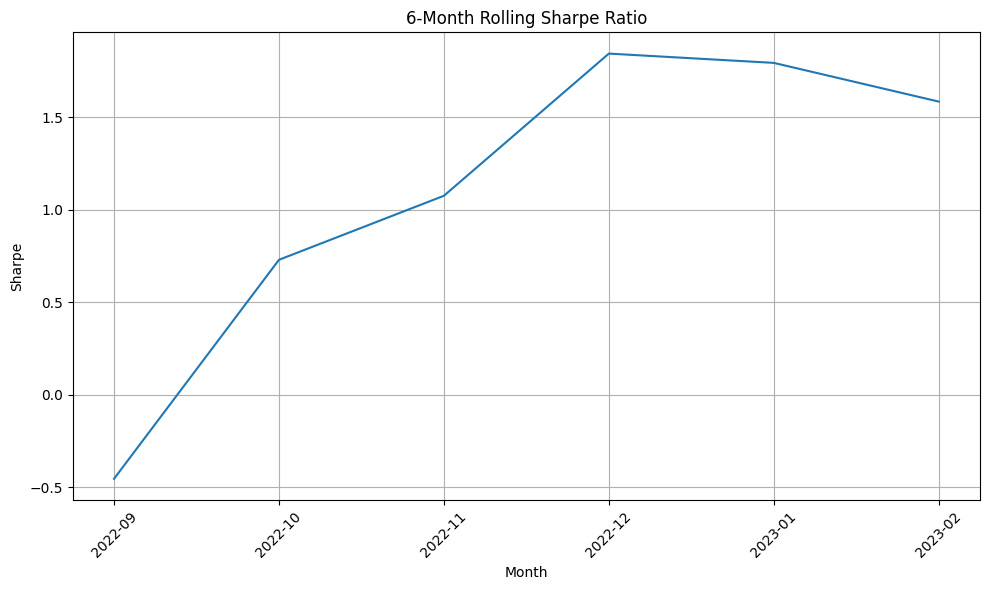

In [ ]:
# rolling sharpe
window = 6  # 6-month rolling Sharpe

rolling_mean = strict_df["spread_net"].rolling(window).mean()
rolling_std = strict_df["spread_net"].rolling(window).std()

rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(12)

plt.figure(figsize=(10,6))
plt.plot(strict_df["month"].astype(str), rolling_sharpe)
plt.xticks(rotation=45)
plt.title("6-Month Rolling Sharpe Ratio")
plt.xlabel("Month")
plt.ylabel("Sharpe")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# performance table
summary = pd.DataFrame({
    "Metric": ["Annual Return", "Volatility", "Sharpe Ratio", "Max Drawdown"],
    "Value": [annual_return, annual_vol, sharpe, max_dd]
})

print(summary)
summary.to_csv("../results/tables/summary.csv")

          Metric     Value
0  Annual Return  0.341489
1     Volatility  0.230195
2   Sharpe Ratio  1.483481
3   Max Drawdown -0.078358


T-test

In [20]:
strict_df.tail()

,month,spread,spread_net,cumulative
6,2022-10,0.081430,0.071430,1.034484
7,2022-11,0.069023,0.059023,1.095542
8,2022-12,0.198052,0.188052,1.301561
9,2023-01,0.020769,0.010769,1.315578
10,2023-02,0.005035,-0.004965,1.309046


In [14]:
t_stat, p_value = stats.ttest_1samp(strict_df["spread_net"], 0)

print("\nT-TEST RESULTS")
print("Mean monthly return:", strict_df["spread_net"].mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)


T-TEST RESULTS
Mean monthly return: 0.026666156503234437
T-statistic: 1.3309203633344415
P-value: 0.21276277008530614


information coefficient

In [15]:
# Remove rows without lagged predictions
ic_data = test_data.dropna(subset=["predicted_return_lagged"])

ic, ic_pval = spearmanr(
    ic_data["predicted_return_lagged"],
    ic_data["ret_1m"]
)

print("\nINFORMATION COEFFICIENT")
print("IC:", ic)
print("IC p-value:", ic_pval)


INFORMATION COEFFICIENT
IC: 0.05666752400217099
IC p-value: 0.005419732168932225


In [21]:
strict_df.to_pickle("../data/processed/llm_strategy_results.pkl")
print("LLM results saved")

LLM results saved
